In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import Layer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import glob
import os
import csv
import shutil


In [79]:
# --- Mixed precision for performance ---
#mixed_precision.set_global_policy('mixed_float16')

# --- Config ---
CONFIG = {
    "DATA_DIR": Path("TrainingData/indicators_data/processed/stocksData"),
    "FORECAST_DIR": Path("forecasts"),
    "CACHE_DIR": Path("cache"),
    "WINDOW_SIZE": 90,
    "TRAIN_VAL_FRAC": 0.8,
    "VAL_FRAC_WITHIN_TRAIN": 0.2,
    "MC_DROPOUT_SAMPLES": 25,
    "EXCLUDED_COLS": ["date", "Target_1d", "Target_1w", "Target_1m", "Target_6m"],
    "PROB_THRESHOLD": 0.7,
}

In [80]:
# Ensure dirs exist
CONFIG["FORECAST_DIR"].mkdir(exist_ok=True)
CONFIG["CACHE_DIR"].mkdir(exist_ok=True)

# --- Globals ---
scaler = StandardScaler()
feature_cols = None

In [81]:
# --- MC Dropout ---
class MCDropout(Dropout):
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)

def mc_dropout_predict(model, X, n_samples=50):
    preds = np.array([model(X, training=True).numpy() for _ in range(n_samples)])
    return preds.mean(axis=0), preds.std(axis=0), preds

In [82]:
# --- Data processing helpers ---
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df["Target_1d"] = np.log(df["close"].shift(-1) / df["close"])
    df["Target_1w"] = np.log(df["close"].shift(-5) / df["close"]) #Only 5 trading days in one week
    df["Target_1m"] = np.log(df["close"].shift(-21) / df["close"]) #Only 21 trading days in one month
    df["Target_6m"] = np.log(df["close"].shift(-126) / df["close"]) #Only 126 trading days in six months
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df

def process_stock(csv_path: Path, for_training=True):
    df = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
    df = add_features(df)
    if df.empty:
        return np.array([]), np.array([]), df, np.array([])

    global feature_cols
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0

    features_scaled = scaler.transform(df[feature_cols].values)
    dates = df["date"].values
    target = df[["Target_1d", "Target_1w", "Target_1m", "Target_6m"]].values if for_training else None

    X, y, y_dates = [], [], []
    for i in range(CONFIG["WINDOW_SIZE"], len(features_scaled)):
        X.append(features_scaled[i - CONFIG["WINDOW_SIZE"]:i + 1])
        if for_training:
            y.append(target[i])
        y_dates.append(dates[i])

    return (
        np.array(X),
        np.array(y) if for_training else None,
        df,
        np.array(y_dates, dtype="datetime64[ns]"),
    )

In [83]:
# --- Cache preprocessed stock ---
def cache_preprocessed_stock(csv_path: Path, train_cutoff, train_val_cutoff):
    stock_name = csv_path.stem
    print(f"Rebuilding cache for: {stock_name}")

    X, y, _, y_dates = process_stock(csv_path, for_training=True)
    if X.size == 0:
        for split in ["train", "val", "test"]:
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", np.array([]))
            np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", np.array([]))
        return

    y_dates = pd.to_datetime(y_dates)
    splits = {
        "train": y_dates < np.datetime64(train_cutoff),
        "val": (y_dates >= np.datetime64(train_cutoff)) & (y_dates < np.datetime64(train_val_cutoff)),
        "test": y_dates >= np.datetime64(train_val_cutoff),
    }
    for split, mask in splits.items():
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{split}.npy", X[mask])
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{split}.npy", y[mask])
        np.save(CONFIG["CACHE_DIR"] / f"{stock_name}_y_dates_{split}.npy", y_dates[mask])

    print(
        f"Cached {stock_name}: "
        + ", ".join([f"{s}={np.sum(m)}" for s, m in splits.items()])
    )

In [84]:
# --- Data generator ---
class StockDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, csv_paths, batch_size=512, split="train", shuffle=True, use_time_weights=True, decay_factor = 0.001):
        self.csv_paths = csv_paths
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.split = split
        self.use_time_weights = use_time_weights
        self.decay_factor = decay_factor
        self.windows = []
        self.stock_names = [Path(p).stem for p in csv_paths]
        self._prepare_indices()
        self.on_epoch_end()

    def _prepare_indices(self):
        self.windows = []
        self.lengths = {}
        self.date_arrays = {}
        for stock_name in self.stock_names:
            X_path = CONFIG["CACHE_DIR"] / f"{stock_name}_X_{self.split}.npy"
            y_path = CONFIG["CACHE_DIR"] / f"{stock_name}_y_{self.split}.npy"
            date_path = CONFIG["CACHE_DIR"] / f"{stock_name}_y_dates_{self.split}.npy"
            if not X_path.exists():
                n_windows = 0
            else:
                X = np.load(X_path, mmap_mode="r")
                n_windows = len(X)
                if date_path.exists():
                    self.date_arrays[stock_name] = np.load(date_path, allow_pickle=True)
            self.lengths[stock_name] = n_windows
            for i in range(n_windows):
                self.windows.append((stock_name, i))
        self.indices = np.arange(len(self.windows))

    def __len__(self):
        return int(np.ceil(len(self.windows) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        X_batch, y_batch, weights_batch = [], [], []
        cache = {}
        for bi in batch_indices:
            stock_name, win_idx = self.windows[bi]
            if stock_name not in cache:
                X = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_X_{self.split}.npy", mmap_mode="r")
                y = np.load(CONFIG["CACHE_DIR"] / f"{stock_name}_y_{self.split}.npy", mmap_mode="r")
                cache[stock_name] = (X, y)
            X_arr, y_arr = cache[stock_name]
            X_batch.append(X_arr[win_idx])
            y_batch.append(y_arr[win_idx])

            if self.use_time_weights and stock_name in self.date_arrays:
                dates = self.date_arrays[stock_name]
                date = pd.to_datetime(dates[win_idx])
                #Give more weight to recent dates now
                date_ago = (pd.Timestamp.now() - date).days
                weights_batch.append(np.exp(-self.decay_factor * date_ago))
            else:
                weights_batch.append(1.0)



        return (np.array(X_batch, dtype=np.float32), 
                np.array(y_batch, dtype=np.float32),
                np.array(weights_batch, dtype=np.float32))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [85]:
# --- Forecast helper ---
def make_forecast(model, X, dates, closes, horizons, horizon_days):
    y_pred_mean, y_pred_std, _ = mc_dropout_predict(model, X, n_samples=CONFIG["MC_DROPOUT_SAMPLES"])
    

    df_dict = {"Date": dates, "Close": closes}

    for i, h in enumerate(horizons):
        df_dict[f"Pred_LogR_{h}"] = y_pred_mean[:, i]
        df_dict[f"Pred_LogR_{h}"] = y_pred_std[:, i]
        days = horizon_days[i]
        df_dict[f"Pred_LogR_PerDayStd_{h}"] = y_pred_std[:, i] / np.sqrt(days)

    forecasting_df = pd.DataFrame(df_dict)
    return forecasting_df

# === MAIN PIPELINE ===
all_csvs = sorted(glob.glob(str(CONFIG["DATA_DIR"] / "*.csv")))
print(f"Found {len(all_csvs)} stocks")

Found 31 stocks


In [86]:
# --- Determine global cutoffs & fit scaler ---
global_min_date, global_max_date = None, None
scaler_inputs = []
feature_cols = None

for csv_path in all_csvs:
    df_tmp = pd.read_csv(csv_path, parse_dates=["date"])
    if global_min_date is None or df_tmp["date"].min() < global_min_date:
        global_min_date = df_tmp["date"].min()
    if global_max_date is None or df_tmp["date"].max() > global_max_date:
        global_max_date = df_tmp["date"].max()

train_val_cutoff = global_min_date + (global_max_date - global_min_date) * CONFIG["TRAIN_VAL_FRAC"]
train_cutoff = global_min_date + (train_val_cutoff - global_min_date) * (1 - CONFIG["VAL_FRAC_WITHIN_TRAIN"])

for csv_path in all_csvs:
    df = pd.read_csv(csv_path, parse_dates=["date"]).sort_values("date").dropna()
    df = add_features(df)
    if df.empty:
        continue
    feat_cols = [c for c in df.columns if c not in CONFIG["EXCLUDED_COLS"]]
    if feature_cols is None:
        feature_cols = feat_cols
    train_rows = df[df["date"] < train_cutoff]
    if len(train_rows) > 0:
        scaler_inputs.append(train_rows[feat_cols].values)

X = np.vstack(scaler_inputs)
X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)
scaler.fit(X)
print("Fitted scaler. feature_cols:", feature_cols)


Fitted scaler. feature_cols: ['close', 'YesterdayClose', 'YesterdayOpenLogR', 'YesterdayHighLogR', 'YesterdayLowLogR', 'YesterdayVolumeLogR', 'YesterdayCloseLogR', 'MA10', 'MA20', 'MA30', 'DayOfWeek', 'DayOfMonth', 'MonthNumber', 'EMA10', 'EMA30', 'RSI', 'MACD', 'MACD_Signal', 'BollingerUpper', 'BollingerLower', 'Volatility_10', 'Volatility_20', 'Volatility_30', 'OBV', 'ZScore', 'insider_shares', 'insider_amount', 'insider_buy_flag', 'sentiment', 'num_articles', 'overnight_gap', 'abnormal_vol', 'volatility_5d', 'volatility_20d', 'momentum_5d', 'momentum_20d', 'skew_5d', 'intraday_range', 'sentiment_change']


In [87]:
# --- Cache all data ---
if CONFIG["CACHE_DIR"].exists():
    shutil.rmtree(CONFIG["CACHE_DIR"])
CONFIG["CACHE_DIR"].mkdir(exist_ok=True)

print("Caching all preprocessed stock data...")
for csv_path in all_csvs:
    cache_preprocessed_stock(Path(csv_path), train_cutoff, train_val_cutoff)
print("Done caching.")

Caching all preprocessed stock data...
Rebuilding cache for: AAPL_daily_processed
Cached AAPL_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ABBV_daily_processed
Cached ABBV_daily_processed: train=724, val=1032, test=1163
Rebuilding cache for: ABNB_daily_processed
Cached ABNB_daily_processed: train=0, val=0, test=919
Rebuilding cache for: ACGL_daily_processed
Cached ACGL_daily_processed: train=4017, val=1032, test=1163
Rebuilding cache for: ACN_daily_processed
Cached ACN_daily_processed: train=3604, val=1032, test=1163
Rebuilding cache for: ADBE_daily_processed
Cached ADBE_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ADI_daily_processed
Cached ADI_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ADM_daily_processed
Cached ADM_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ADP_daily_processed
Cached ADP_daily_processed: train=4036, val=1032, test=1163
Rebuilding cache for: ADSK_daily_processe

In [88]:

class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros")        
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)  # attention weights
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

In [89]:
# --- Data generators ---
train_gen = StockDataGenerator(all_csvs, batch_size=128, split="train", shuffle=True, use_time_weights=True, decay_factor=0.002)
val_gen = StockDataGenerator(all_csvs, batch_size=128, split="val", shuffle=False)

In [90]:
#Actual training with the weights now
def generator_with_weights(gen):
    for X, y, w in gen:
        yield X, y, w

train_dataset = tf.data.Dataset.from_generator(
    lambda: generator_with_weights(train_gen),
    output_signature=(
        tf.TensorSpec(shape=(None, CONFIG["WINDOW_SIZE"] + 1, len(feature_cols)), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: generator_with_weights(val_gen),
    output_signature=(
        tf.TensorSpec(shape=(None, CONFIG["WINDOW_SIZE"] + 1, len(feature_cols)), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
        tf.TensorSpec(shape=(None,), dtype=tf.float32),
    )
)

Epoch 1/200
807/807 [==============================] - 44s 52ms/step - loss: 1.6321e-06 - mae: 0.1147 - val_loss: 0.0013 - val_mae: 0.0710
Epoch 2/200
807/807 [==============================] - 36s 45ms/step - loss: 1.1097e-06 - mae: 0.0969 - val_loss: 0.0012 - val_mae: 0.0670
Epoch 3/200
807/807 [==============================] - 38s 47ms/step - loss: 1.0544e-06 - mae: 0.0946 - val_loss: 0.0012 - val_mae: 0.0664
Epoch 4/200
807/807 [==============================] - 38s 47ms/step - loss: 9.9440e-07 - mae: 0.0927 - val_loss: 0.0012 - val_mae: 0.0661
Epoch 5/200
807/807 [==============================] - 38s 47ms/step - loss: 9.6096e-07 - mae: 0.0922 - val_loss: 0.0012 - val_mae: 0.0668
Epoch 6/200
807/807 [==============================] - 36s 45ms/step - loss: 9.4023e-07 - mae: 0.0918 - val_loss: 0.0012 - val_mae: 0.0666
Epoch 7/200
807/807 [==============================] - 38s 48ms/step - loss: 9.1821e-07 - mae: 0.0916 - val_loss: 0.0013 - val_mae: 0.0682
Epoch 8/200
807/807 [======

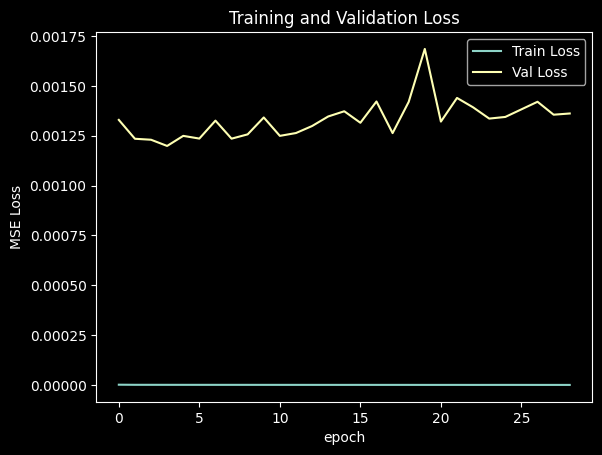

In [ ]:
n_features = len(feature_cols)
model = Sequential([
    Conv1D(32, kernel_size=3, activation="relu", 
           input_shape=(CONFIG["WINDOW_SIZE"] + 1, n_features)),
    BatchNormalization(),
    MCDropout(0.3),
    LSTM(64, return_sequences=False), 
    MCDropout(0.3),
    Dense(32, activation="relu"),
    Dense(4, activation="linear") #Four time horizon predictions as output
])

early_stop = EarlyStopping(
    patience = 25,
    monitor = "val_loss",
    restore_best_weights = True,
    mode = "min",
)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(train_gen, validation_data=val_gen, callbacks=[early_stop],epochs=200)
#history = model.fit(train_gen, validation_data=val_gen,epochs=2)


plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend(); plt.show()

In [92]:
from sklearn.metrics import mean_squared_error

def feature_importance(model, X_val, y_val, feature_names):
    base_preds = model.predict(X_val)
    base_loss = mean_squared_error(y_val, base_preds)
    importances = []

    for i, col in enumerate(feature_names):
        X_val_permuted = X_val.copy()
        np.random.shuffle(X_val_permuted[:, :, i])
        preds = model.predict(X_val_permuted)
        loss = mean_squared_error(y_val, preds)
        importances.append(loss - base_loss)

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False)

    return importance_df


4/4 [==============================] - 0s 9ms/step


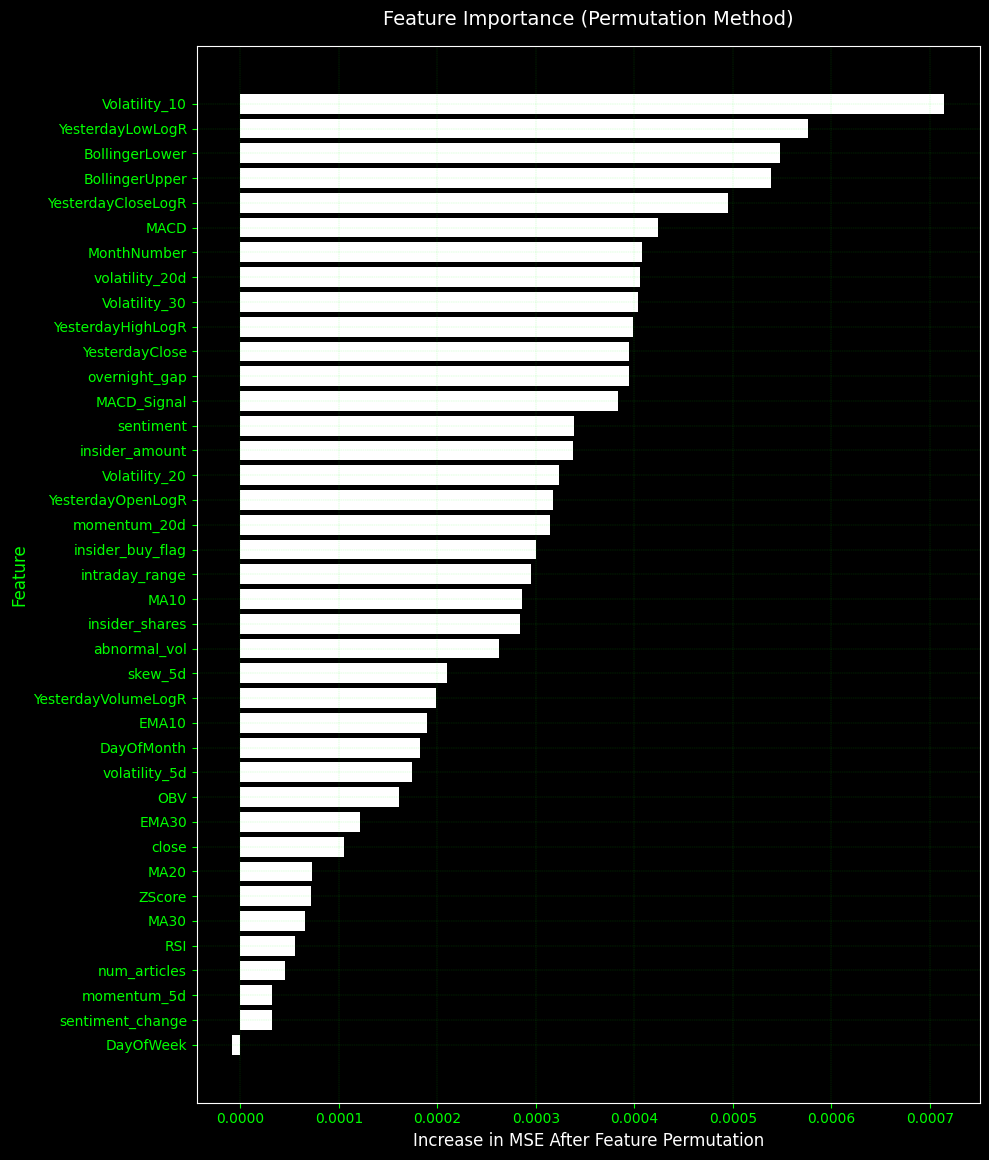

In [93]:
batch = val_gen[0]
if isinstance(batch, tuple):
    if len(batch) == 2:
        X_val, y_val = batch
    elif len(batch) == 3:
        X_val, y_val, _ = batch  # ignore sample weights
    else:
        raise ValueError(f"Unexpected number of outputs: {len(batch)}")
else:
    raise ValueError("val_gen[0] did not return a tuple.")
importance_df = feature_importance(model, X_val, y_val, feature_cols)

#Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.3)))  # dynamically scale height

ax.barh(importance_df["Feature"], importance_df["Importance"], color="white", linewidth=1.2)
ax.set_xlabel("Increase in MSE After Feature Permutation", fontsize=12)
ax.set_ylabel("Feature", color="lime", fontsize=12)
ax.set_title("Feature Importance (Permutation Method)", fontsize=14, pad=15)

# Customize tick labels
ax.tick_params(axis='x', colors='lime')
ax.tick_params(axis='y', colors='lime')

# Optional grid styling
ax.grid(color='lime', linestyle='--', linewidth=0.3, alpha=0.3)

# Flip the order (so most important features at top)
plt.gca().invert_yaxis()


plt.tight_layout()
output_path = CONFIG["FORECAST_DIR"] / "feature_importance.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="black")
plt.show()
# === Save as high-quality PNG ===


In [94]:
# --- Forecasting ---
for file in glob.glob(str(CONFIG["FORECAST_DIR"] / "*.csv")):
    os.remove(file)

horizons = ["1d", "1w", "1m", "6m"]
horizon_days = [1, 5, 21, 126]

print("\nGenerating forecasts...")
for csv_path in all_csvs:
    stock_name = Path(csv_path).stem
    X_all, _, df, y_dates = process_stock(Path(csv_path), for_training=False)
    if X_all.size == 0:
        continue
    y_dates = pd.to_datetime(y_dates)
    test_mask = y_dates >= np.datetime64(train_val_cutoff)
    if not np.any(test_mask):
        continue


    forecast_df = make_forecast(
        model, 
        X_all[test_mask], 
        y_dates[test_mask], 
        df.loc[df["date"].isin(y_dates[test_mask]), "close"].values,
        horizons=horizons,
        horizon_days=horizon_days,
        )

    forecast_df.to_csv(CONFIG["FORECAST_DIR"] / f"{stock_name}_forecast.csv", index=False)

print("Done")


Generating forecasts...
Done
